In [27]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# Leitura do arquivo

arquivo = 'tratados_10x10det/proton/proton1E15_array'

df = pl.read_csv(arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("positrons"))
df = df.with_columns(pl.col("split_column").list.get(2).cast(pl.Int64).alias("electrons"))
df = df.with_columns(pl.col("split_column").list.get(3).cast(pl.Int64).alias("muons_plus"))
df = df.with_columns(pl.col("split_column").list.get(4).cast(pl.Int64).alias("muons_minus"))
df = df.with_columns(
    (pl.col("positrons") + pl.col("electrons") + pl.col("muons_plus") + pl.col("muons_minus")).alias("total_particles")
)

df

column_1,split_column,TRIG,positrons,electrons,muons_plus,muons_minus,total_particles
str,list[str],str,i64,i64,i64,i64,i64
"""TRIG1 0 0 0 0""","[""TRIG1"", ""0"", … ""0""]","""TRIG1""",0,0,0,0,0
"""TRIG2 0 0 0 0""","[""TRIG2"", ""0"", … ""0""]","""TRIG2""",0,0,0,0,0
"""TRIG3 1 0 0 0""","[""TRIG3"", ""1"", … ""0""]","""TRIG3""",1,0,0,0,1
"""TRIG4 0 0 0 0""","[""TRIG4"", ""0"", … ""0""]","""TRIG4""",0,0,0,0,0
"""TRIG5 0 0 0 0""","[""TRIG5"", ""0"", … ""0""]","""TRIG5""",0,0,0,0,0
…,…,…,…,…,…,…,…
"""TRIG96 1 1 0 0""","[""TRIG96"", ""1"", … ""0""]","""TRIG96""",1,1,0,0,2
"""TRIG97 0 1 0 0""","[""TRIG97"", ""0"", … ""0""]","""TRIG97""",0,1,0,0,1
"""TRIG98 0 0 0 1""","[""TRIG98"", ""0"", … ""1""]","""TRIG98""",0,0,0,1,1


In [29]:
import re
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(arquivo)
name

'Proton 1E15'

In [30]:
# Transformação das contagens de partículas em listas e na média de contagens

df2 = df.group_by('TRIG').agg(pl.col('total_particles')).sort(
    pl.col('TRIG').str.extract(r"TRIG([0-9]*)", 1).cast(int)
)
df2 = df2.with_columns(mean_particles = pl.col('total_particles').list.mean())  
df2

TRIG,total_particles,mean_particles
str,list[i64],f64
"""TRIG1""","[0, 0, … 0]",0.315
"""TRIG2""","[0, 0, … 0]",0.421
"""TRIG3""","[1, 0, … 0]",0.552
"""TRIG4""","[0, 0, … 0]",0.61
"""TRIG5""","[0, 0, … 1]",0.661
…,…,…
"""TRIG96""","[0, 1, … 2]",0.724
"""TRIG97""","[0, 0, … 1]",0.594
"""TRIG98""","[0, 0, … 1]",0.562


In [31]:
# Lista dos TRIGS com valores da média 

trigs = df2['mean_particles'].to_list()

In [32]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize + 0.5) * spacing
        y_det[index] = (i - halfGridSize + 0.5) * spacing
        areas[index] = area
        index += 1

print("x_det:", x_det)
print("y_det:", y_det)
print("areas:", areas)


x_det: [-45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.
  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.
  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35.
 -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.
  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45.
 -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.
  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.
  35.  45.]
y_det: [-45. -45. -45. -45. -45. -45. -45. -45. -45. -45. -35. -35. -35. -35.
 -35. -35. -35. -35. -35. -35. -25. -25. -25. -25. -25. -25. -25. -25.
 -25. -25. -15. -15. -15. -15. -15. -15. -15. -15. -15. -15.  -5.  -5.
  -5.  -5.  -5.  -5.  -5.  -5.  -5.  -5.   5.   5.   5.   5.   5.   5.
   5.   5.   5.   5.  15.  15.  15.  15.  15.  15.  15.  15.  15.  15.
  25.  25.  25.  25.  25.  25.  25.  25.  25.  25.  35.  35.  35.  35.
  35.  35.  35.  35.  35.  35.  45.  45.  45.  45. 

Text(62.722222222222214, 0.5, 'y (m)')

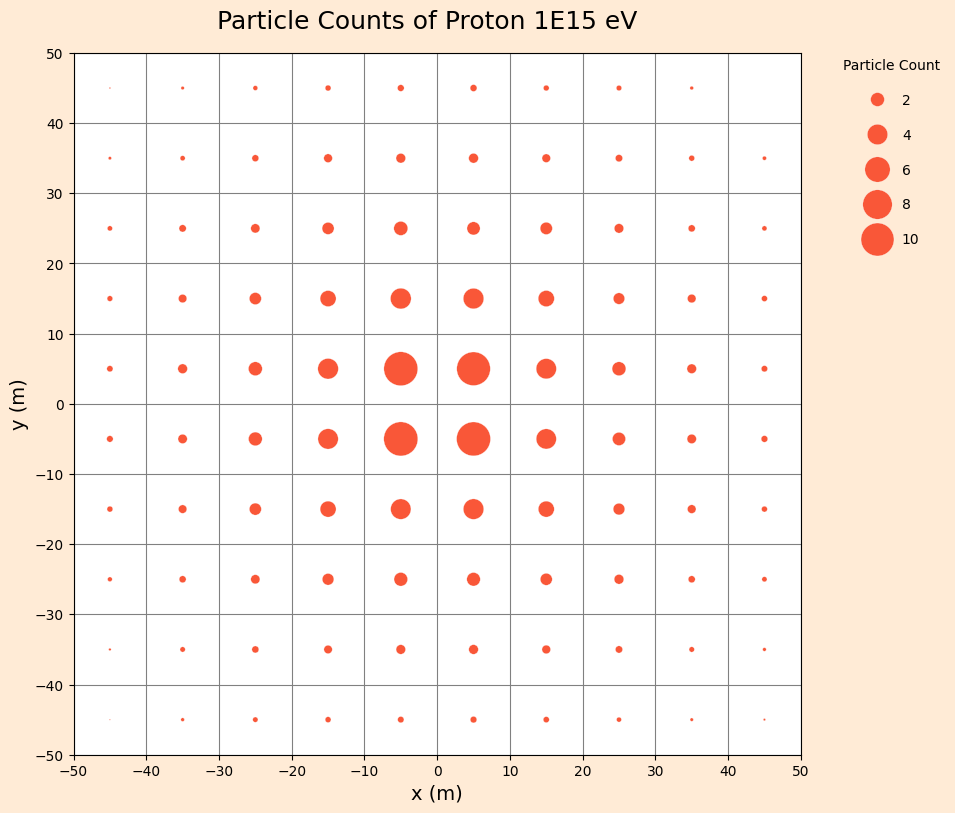

In [33]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Particle Counts of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

scatter = sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs, sizes=(0, 600), legend = 'brief')
handles, labels = scatter.get_legend_handles_labels()
for handle in handles:
    handle.set_color('#F95738')
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
           frameon=False, title='Particle Count', labelspacing = 1.5)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


#plt.savefig('plots/counts_' + str(arquivo) + '.png', bbox_inches = 'tight', dpi = 300)

In [ ]:
# O primeiro índice é o trig do tanque, e o segundo é o evento. Apenas um exemplo
#df2['count'][0][0]*x_det[0]+df2['count'][1][0]*x_det[1]+ df2['count'][2][0]*x_det[2]/(df2['count'][0][0]+df2['count'][1][0]+df2['count'][2][0])

np.float64(-939.2105263157895)

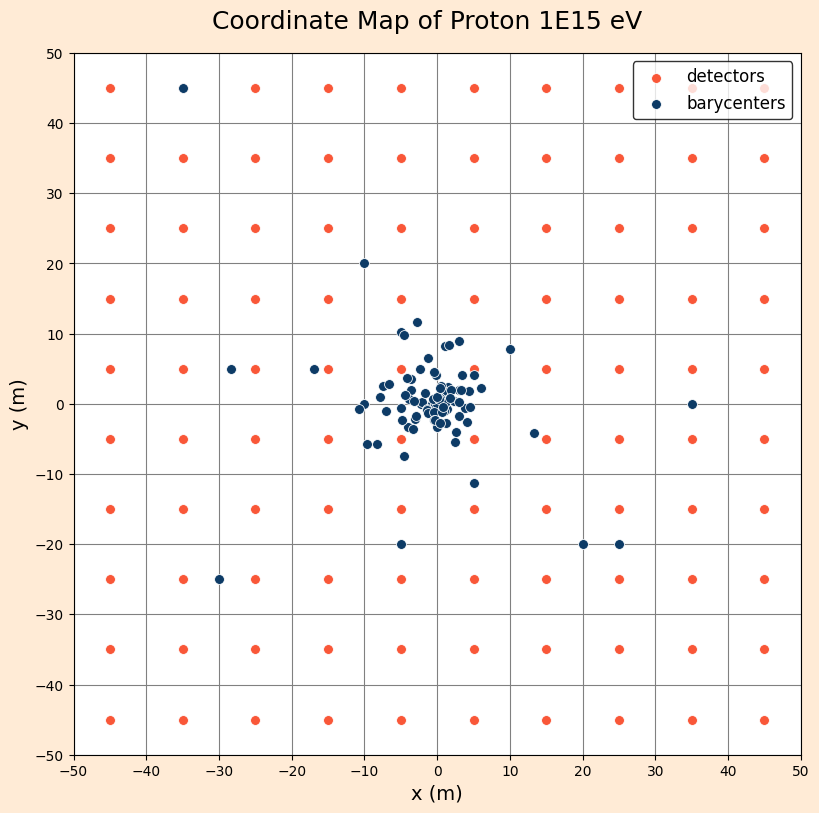

In [34]:
# Posição dos baricentros
x_b = [0] * len(trigs)
y_b = [0] * len(trigs)

for i in range(len(trigs)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (df2['total_particles'][j][i]*x_det[j])
                numerator1 += (df2['total_particles'][j][i]*y_det[j])
                denominator += (df2['total_particles'][j][i])
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/map_' + str(arquivo) + '.png',bbox_inches = 'tight', dpi = 300)

In [23]:
# Criação de arquivo de dados para construir a função de distribuição lateral

r_b = []
for i in range(100):
    aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    r_b.append(aux)


df3 = df2.with_columns(
    pl.Series(name='x_b', values=x_b),
    pl.Series(name='y_b', values=y_b),
    pl.Series(name='r_b', values=r_b)
)

df3 = df3.drop('count')
#df3.write_csv('array_dat/' + arquivo + '_fdl.csv', separator= '\t', has_header= False)

[1.72491233e-15 2.53350048e-01]
[3.75935697 4.22144806 4.68582022 5.14936186 5.61145295 6.07582511]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_8340\3126602386.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_8340\3126602386.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.281715,14.0,13.656374,2.454472
4.611511,14.332438,14.613058,1.957934
4.98322,14.666518,14.880474,1.458806
5.121888,15.0,14.980235,0.131769
5.601082,15.332438,15.324977,0.048663
5.903849,15.666518,15.542795,0.78973


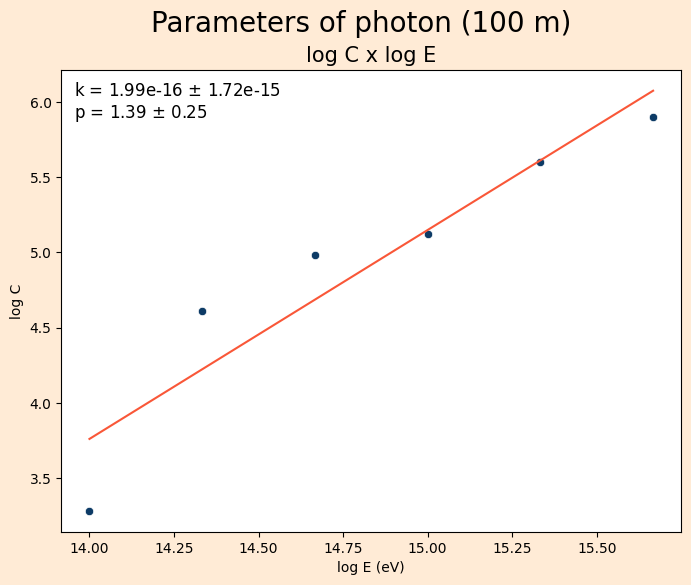

In [24]:
# Fit do fóton
from scipy.optimize import curve_fit

C = [1913,4.088E4,9.621E4,1.324E5,3.991E5,8.014E5]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[1.28101746e-11 1.21594918e-01]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_8340\4179547870.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_8340\4179547870.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.999783,14.0,13.882234,0.841186
4.485437,14.332438,14.316894,0.108456
4.953663,14.666518,14.735955,0.47344
5.480725,15.0,15.207675,1.3845
5.650696,15.332438,15.359798,0.178444
5.802158,15.666518,15.495356,1.092531


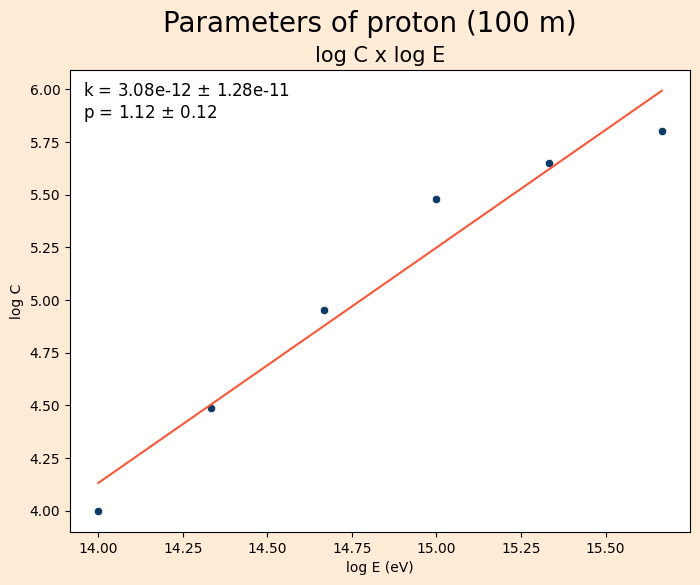

In [25]:
# Fit do próton

C = [9995,3.058E4,8.988E4,3.025E5,4.474E5,6.341E5]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_proton[0]))/coefficients_proton[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[3.42582837e-27 2.58196398e-01]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_8340\1559789262.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_8340\1559789262.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
1.951872,14.0,13.770893,1.636482
3.528788,14.332438,14.510452,1.242031
4.044932,14.666518,14.752518,0.586372
4.768268,15.0,15.091756,0.611709
5.263399,15.332438,15.323968,0.055243
5.741782,15.666518,15.548325,0.754428


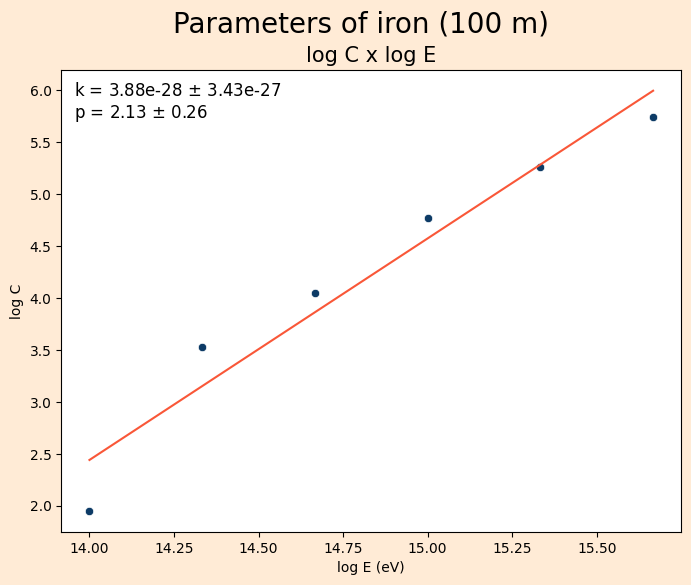

In [26]:
# Fit do ferro

C = [89.51,3379,1.109E4,5.865E4,1.834E5,5.518E5]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_iron, cov = curve_fit(power, E, np.log10(C), p0=initial_guess, maxfev = 1000)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients_iron), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_iron[0],inc[0],coefficients_iron[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_iron[0]))/coefficients_iron[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [27]:
# Reconstrução da energia

E_real = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
r0 = 7800

# Parâmetros fóton

k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = [285.2,3.471E4,8.548E4,1.273E5,3.643E5,5.754E5] # Array 10x10
E_photon = []


for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)
    #N = ((c_photon[i])/((r0**(s_photon[i]))))*(1000**((s_photon[i]-1))/(s_photon[i]-1))*math.pi*1000**2
    #N_photon.append(N)
    #print('{:e}'.format(E_photon[i]))


# Parâmetros próton

k_proton = coefficients_proton[0]
p_proton = coefficients_proton[1]
c_proton = [9558,2.796E4,9.591E4,3.025E5,2.992E5,4.638E5]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)
    #print('{:e}'.format(E_proton[i]))

# Parâmetros ferro

k_iron = coefficients_iron[0]
p_iron = coefficients_iron[1]
c_iron = [70.36,3729,1215,6.395E4,1.823E5,6.018E5]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    #print('{:e}'.format(E_iron[i]))


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_iron
f64,f64,f64,f64
1.0000e14,1.1527e13,7.3258e13,5.2706e13
2.1500e14,3.6470e14,1.9146e14,3.3926e14
4.6400e14,6.9747e14,5.7703e14,2.0050e14
1.0000e15,9.2888e14,1.6132e15,1.2864e15
2.1500e15,1.9791e15,1.5974e15,2.1025e15
4.6400e15,2.7497e15,2.3648e15,3.6812e15


[Text(0.5, 1.0, 'Energy relative deviation $\\Delta$E/E')]

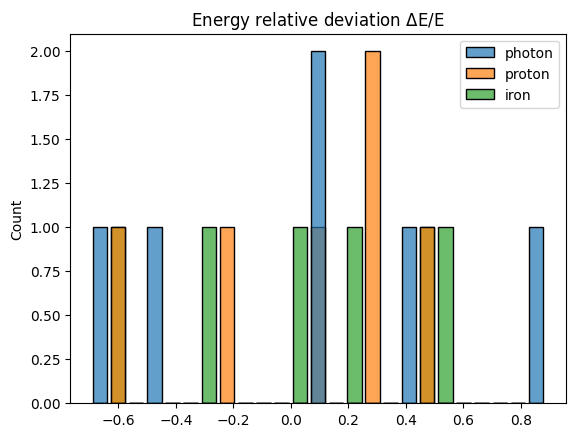

In [28]:
DeltaE_photon = []
DeltaE_proton = []
DeltaE_iron = []

for i in range(len(E_real)):
    aux = (E_real[i] - E_photon[i])/E_real[i]
    aux2 = (E_real[i] - E_proton[i])/E_real[i]
    aux3 = (E_real[i] - E_iron[i])/E_real[i]
    DeltaE_photon.append(aux)
    DeltaE_proton.append(aux2)
    DeltaE_iron.append(aux3)

data = {
    'photon':DeltaE_photon,
    'proton':DeltaE_proton,
    'iron':DeltaE_iron
}

sns.histplot(data=data, bins= 25, shrink=0.8, alpha = 0.7).set(title = 'Energy relative deviation $\Delta$E/E')